# Section 0. 목적과 전체 파이프라인

VoD FMCW 지상감지 **레이더 포인트**는 밀도가 높고 잡음·다중경로가 섞여 **raw point를 곧바로 분류**하기 어렵다. 본 노트북은 **클러스터 후보 → 억제 → LiDAR 검증 → 트래킹 → 규칙 점수 → ML → hybrid 랭킹**으로 위험 **순위(ranking)**를 만든다.

- **Ranking**: 운영에서는 모든 포인트보다 **상위 k개 후보**에 자원을 집중하는 것이 현실적이다.
- **Honest evaluation**: `random` split은 낙관적일 수 있어 **최종 요약·결론에는 사용하지 않는다.** `group_frame` / `time` / `contiguous_block`과 anti-leakage feature만 최종 보고에 쓴다.

파이프라인 코어는 `vod_e2e_pipeline`, `vod_hybrid_pipeline_stage3`, `vod_hybrid_pipeline_v2`, `bev_lidar_detector_train`을 사용하고, **보고·플롯·저장·assert는 이 노트북 안**에만 있다.


In [57]:
# --- Section util: paths, seed, timing, save, optional deps ---
from __future__ import annotations

import importlib.util
import logging
import os
import random
import sys
import time
import warnings
from contextlib import contextmanager
from pathlib import Path
from typing import Any, Callable

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager, rc

try:
    from IPython.display import display as ipy_display
except Exception:
    def ipy_display(obj: Any) -> None:
        print(obj if not hasattr(obj, "head") else obj.head())

try:
    import hdbscan  # noqa: F401
    HDBSCAN_OK = True
except Exception:
    HDBSCAN_OK = False

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

NOTEBOOK_TAG = "single_ipynb"
runtime_records: list[dict[str, float | str]] = []


def resolve_vod_devkit_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(12):
        if (p / "bev_lidar_detector_train.py").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError("vod-devkit root not found (bev_lidar_detector_train.py). cwd=" + str(Path.cwd()))


NOTEBOOK_DIR = resolve_vod_devkit_root()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import bev_lidar_detector_train as bev  # noqa: E402
import vod_e2e_pipeline as e2e  # noqa: E402
import vod_hybrid_pipeline_stage3 as s3  # noqa: E402
import vod_hybrid_pipeline_v2 as v2  # noqa: E402

RESULT_ROOT = NOTEBOOK_DIR / "results"
FIG_DIR = RESULT_ROOT / "figures"
TABLE_DIR = RESULT_ROOT / "tables"
ART_DIR = RESULT_ROOT / "artifacts"
for _p in (RESULT_ROOT, FIG_DIR, TABLE_DIR, ART_DIR):
    _p.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

OPT = {
    "hdbscan": HDBSCAN_OK,
    "shap": importlib.util.find_spec("shap") is not None,
    "xgboost": importlib.util.find_spec("xgboost") is not None,
    "lightgbm": importlib.util.find_spec("lightgbm") is not None,
    "catboost": importlib.util.find_spec("catboost") is not None,
}

FONT_PATH = "C:/Windows/Fonts/malgun.ttf"
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if Path(FONT_PATH).is_file():
    font_manager.fontManager.addfont(FONT_PATH)
    primary_font = font_manager.FontProperties(fname=FONT_PATH).get_name()
else:
    primary_font = "Malgun Gothic" if "Malgun Gothic" in available_fonts else None
font_candidates = [primary_font, "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
active_fonts: list[str] = []
for fam in font_candidates:
    if fam and fam in available_fonts and fam not in active_fonts:
        active_fonts.append(fam)
sns.set_theme(style="whitegrid")
if active_fonts:
    rc("font", family=active_fonts)
    matplotlib.rcParams["font.family"] = active_fonts
rc("axes", unicode_minus=False)
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120


@contextmanager
def timed(stage: str):
    t0 = time.perf_counter()
    yield
    dt = time.perf_counter() - t0
    runtime_records.append({"stage": stage, "sec": float(dt)})
    print(f"[timed] {stage}: {dt:.3f}s")


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / f"{name}_{NOTEBOOK_TAG}.csv"
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("[saved table]", path)
    return path


def save_fig(name: str) -> Path:
    path = FIG_DIR / f"{name}_{NOTEBOOK_TAG}.png"
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print("[saved fig]", path)
    return path


print("NOTEBOOK_DIR=", NOTEBOOK_DIR)
print("HDBSCAN_OK=", HDBSCAN_OK, "OPT=", OPT)


NOTEBOOK_DIR= C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit
HDBSCAN_OK= True OPT= {'hdbscan': True, 'shap': False, 'xgboost': False, 'lightgbm': False, 'catboost': False}


In [58]:
# --- Plot helpers + anti-leakage assert (notebook-local) ---


def _stats_md(name: str, s: pd.Series) -> str:
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return f"**{name}**: (empty)\n"
    q10, q50, q90 = s.quantile(0.1), s.quantile(0.5), s.quantile(0.9)
    return (
        f"**{name}**: mean={s.mean():.4g}, median={q50:.4g}, p10={q10:.4g}, p90={q90:.4g}, "
        f"std={s.std():.4g}, nonzero_ratio={(s.abs() > 1e-9).mean():.3f}\n"
    )


def raw_radar_eda_extended(
    radar_df: pd.DataFrame,
    frame_summary: pd.DataFrame,
    *,
    save_fig_fn: Callable[[str], Path],
    seed: int = 42,
) -> str:
    lines = ["### Raw point 통계 (요약)\n"]
    for col in ["RCS", "v_r_compensated", "range_xy", "abs_vr_comp"]:
        if col in radar_df.columns:
            lines.append(_stats_md(col, radar_df[col]))
    lines.append(
        f"- **frame별 point 수**: mean={frame_summary['raw_points'].mean():.1f}, "
        f"median={frame_summary['raw_points'].median():.1f}\n"
    )
    lines.append(
        f"- **전처리 전/후 kept ratio**: mean frame kept_ratio={frame_summary['kept_ratio'].mean():.3f}\n"
    )
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    sns.histplot(radar_df["RCS"], bins=40, ax=axes[0])
    axes[0].set_title("RCS")
    sns.histplot(radar_df["v_r_compensated"], bins=40, ax=axes[1])
    axes[1].set_title("v_r_compensated")
    sns.histplot(radar_df["range_xy"], bins=40, ax=axes[2])
    axes[2].set_title("range_xy")
    sns.histplot(radar_df["abs_vr_comp"], bins=40, ax=axes[3])
    axes[3].set_title("abs_vr_comp")
    fc = frame_summary.groupby("frame_order")["raw_points"].sum()
    axes[4].plot(fc.index, fc.values, lw=1.0)
    axes[4].set_title("Frame별 raw point count")
    sxy = radar_df.sample(min(8000, len(radar_df)), random_state=seed)
    sc = axes[5].scatter(sxy["x"], sxy["y"], c=sxy["abs_vr_comp"], s=3, alpha=0.35, cmap="coolwarm")
    axes[5].set_aspect("equal", adjustable="box")
    axes[5].set_title("Radar XY (color=|vr|)")
    plt.colorbar(sc, ax=axes[5])
    plt.tight_layout()
    save_fig_fn("sec02_raw_eda_extended")
    plt.close()
    return "".join(lines)


def label_conditioned_cluster_eda(
    cluster_df: pd.DataFrame,
    *,
    score_col: str = "risk_score_rule_v2",
    label_col: str = "risk_label_rule_v2",
    save_fig_fn: Callable[[str], Path],
    tag: str = "",
) -> None:
    d = cluster_df.copy()
    if label_col in d.columns:
        d["_bin"] = d[label_col].astype(str)
    else:
        d["_bin"] = pd.qcut(d[score_col].rank(method="first"), 3, labels=["low_q", "mid_q", "high_q"])
    metrics = [
        c
        for c in [
            "mean_rcs",
            "abs_vr_comp",
            "range_xy",
            "n_points",
            "spread_xy",
            "density_proxy",
            "vr_comp_std",
            "lidar_corroboration_score_v2",
            "track_len",
            "approach_score",
            "closing_consistency_score",
        ]
        if c in d.columns
    ]
    if not metrics:
        return
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    sns.boxplot(data=d, x="_bin", y=metrics[0], ax=axes[0, 0])
    axes[0, 0].set_title(metrics[0])
    if len(metrics) > 1:
        sns.violinplot(data=d, x="_bin", y=metrics[1], ax=axes[0, 1], inner="box")
        axes[0, 1].set_title(metrics[1])
    if len(metrics) > 2:
        sns.boxplot(data=d, x="_bin", y=metrics[2], ax=axes[1, 0])
        axes[1, 0].set_title(metrics[2])
    if len(metrics) > 3:
        sns.boxplot(data=d, x="_bin", y=metrics[3], ax=axes[1, 1])
        axes[1, 1].set_title(metrics[3])
    plt.suptitle("Label / quantile-conditioned cluster features " + tag, y=1.02)
    plt.tight_layout()
    save_fig_fn("sec20_label_conditioned_" + tag.replace(" ", "_"))
    plt.close()


def cluster_level_tables(
    cluster_df_raw: pd.DataFrame,
    cluster_df_suppressed: pd.DataFrame,
    *,
    save_fig_fn: Callable[[str], Path],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    cols = [
        c
        for c in [
            "n_points",
            "spread_xy",
            "mean_rcs",
            "mean_vr_comp",
            "vr_comp_std",
            "density_proxy",
            "proposal_quality_score",
        ]
        if c in cluster_df_suppressed.columns
    ]
    desc_sup = cluster_df_suppressed[cols].describe(percentiles=[0.1, 0.5, 0.9]).T if cols else pd.DataFrame()
    if cols and len(cluster_df_suppressed):
        fig, ax = plt.subplots(figsize=(10, 4))
        q = (
            cluster_df_suppressed["proposal_quality_score"]
            if "proposal_quality_score" in cluster_df_suppressed.columns
            else cluster_df_suppressed.get("density_proxy")
        )
        if q is not None:
            sns.histplot(q.dropna(), bins=40, ax=ax)
            ax.set_title("Cluster quality / density proxy (suppressed)")
            plt.tight_layout()
            save_fig_fn("sec05_cluster_quality_hist")
            plt.close()
    return desc_sup, cluster_df_raw.head(8), cluster_df_suppressed.head(8)


def track_level_eda(track_obs: pd.DataFrame, *, save_fig_fn: Callable[[str], Path]) -> pd.DataFrame:
    cols = [
        c
        for c in [
            "track_len",
            "track_age",
            "approach_score",
            "heading_consistency_score",
            "closing_consistency_score",
            "motion_smoothness_score",
        ]
        if c in track_obs.columns
    ]
    if not cols:
        return pd.DataFrame()
    desc = track_obs[cols].describe(percentiles=[0.1, 0.5, 0.9]).T
    n = min(3, len(cols))
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5))
    if n == 1:
        axes = [axes]
    for ax, c in zip(axes, cols[:n]):
        sns.histplot(track_obs[c].dropna(), bins=35, ax=ax)
        ax.set_title(c)
    plt.tight_layout()
    save_fig_fn("sec07_track_temporal_dists")
    plt.close()
    return desc


def temporal_feature_distribution_report(track_obs: pd.DataFrame) -> pd.DataFrame:
    temporal_cols = [
        c
        for c in [
            "approach_score",
            "temporal_stability_score",
            "heading_consistency_score",
            "closing_consistency_score",
            "motion_smoothness_score",
        ]
        if c in track_obs.columns
    ]
    rows = []
    for c in temporal_cols:
        s = pd.to_numeric(track_obs[c], errors="coerce")
        rows.append(
            {
                "feature": c,
                "mean": float(s.mean()),
                "std": float(s.std()),
                "median": float(s.median()),
                "p90": float(s.quantile(0.9)),
                "nonzero_ratio": float((s.abs() > 1e-9).mean()),
            }
        )
    return pd.DataFrame(rows)


TARGET_HELPER_COLS = frozenset({"hard_tmp", "ml_high_prob_raw", "ml_high_prob_selected"})


def assert_ab_feature_sets_clean(fs_dict: dict[str, list[str]]) -> pd.DataFrame:
    banned = frozenset(e2e.LEAKAGE_BLACKLIST | e2e.RULE_SCORE_LIKE | TARGET_HELPER_COLS)
    rows = []
    for fs_name in ("A_strict_anti_leakage", "B_moderate_anti_leakage"):
        cols_set = set(fs_dict[fs_name])
        inter = sorted(cols_set & banned)
        rows.append({"feature_set": fs_name, "blacklist_hits": ", ".join(inter), "passed": len(inter) == 0})
        if inter:
            raise AssertionError(f"Anti-leakage FAIL {fs_name}: {inter}")
    return pd.DataFrame(rows)


def pick_best_any_split(exp: pd.DataFrame) -> pd.Series:
    sub = exp[(exp["task"] == "classification") & (exp["feature_set"].isin(["A_strict_anti_leakage", "B_moderate_anti_leakage"])) & exp["macro_f1"].notna()].copy()
    if sub.empty:
        return pd.Series(dtype=float)
    sub["_score"] = sub["macro_f1"] * 0.45 + sub["high_recall"] * 0.35 + sub["ranking_ap"].fillna(0) * 0.20
    return sub.sort_values(["_score", "macro_f1"], ascending=False).iloc[0]


def pick_best_honest_only(exp: pd.DataFrame) -> pd.Series:
    sub = exp[
        (exp["task"] == "classification")
        & (exp["feature_set"].isin(["A_strict_anti_leakage", "B_moderate_anti_leakage"]))
        & (exp["split"].isin(e2e.HONEST_SPLITS))
        & exp["macro_f1"].notna()
    ].copy()
    if sub.empty:
        raise RuntimeError("No honest classification rows")
    sub["_score"] = sub["macro_f1"] * 0.45 + sub["high_recall"] * 0.35 + sub["ranking_ap"].fillna(0) * 0.20
    return sub.sort_values(["_score", "macro_f1"], ascending=False).iloc[0]


print("[HR] Plot helpers + anti-leakage assert 준비 완료. 다음 셀부터 섹션별 실행.")


[HR] Plot helpers + anti-leakage assert 준비 완료. 다음 셀부터 섹션별 실행.


## Section 1. 환경 설정

아래 코드에서 `DATASET_ROOT`, `MAX_FRAMES`, ROI 등을 고정한다. optional dependency는 부스터 모델 활성화 여부만 표시한다.


In [59]:
DEFAULT_ROOT = NOTEBOOK_DIR / "vod-received" / "view_of_delft_PUBLIC"
DATASET_ROOT = Path(os.environ.get("VOD_ROOT", str(DEFAULT_ROOT))).resolve()
RADAR_MODE = os.environ.get("VOD_RADAR_MODE", "5-scan")
MAX_FRAMES = int(os.environ.get("VOD_REDESIGN_MAX_FRAMES", "180"))
MAX_POINTS_PER_FRAME = int(os.environ.get("VOD_REDESIGN_MAX_POINTS_PER_FRAME", "2200"))
ROI = {"x_min": 0.0, "x_max": 70.0, "y_min": -35.0, "y_max": 35.0, "z_min": -3.5, "z_max": 4.0}
RCS_CLIP = (-35.0, 35.0)
SPEED_CLIP = (-25.0, 25.0)
DBSCAN_EPS = float(os.environ.get("VOD_DBSCAN_EPS", "1.2"))
DBSCAN_MIN_SAMPLES = int(os.environ.get("VOD_DBSCAN_MIN_SAMPLES", "6"))
TRACK_GATE_DIST = float(os.environ.get("VOD_TRACK_GATE_DIST", "3.5"))

env_summary_df = pd.DataFrame(
    [
        {"key": k, "value": v}
        for k, v in {
            "NOTEBOOK_DIR": str(NOTEBOOK_DIR),
            "DATASET_ROOT": str(DATASET_ROOT),
            "RADAR_MODE": RADAR_MODE,
            "MAX_FRAMES": MAX_FRAMES,
            "MAX_POINTS_PER_FRAME": MAX_POINTS_PER_FRAME,
            **{f"opt_{k}": v for k, v in OPT.items()},
        }.items()
    ]
)
ipy_display(env_summary_df)
save_table(env_summary_df, "sec01_config")
print("[HR 해석] 시드와 경로를 고정해 Run All 재현성을 확보했다. 다음 셀에서 프레임을 적재한다.")


,key,value
0,NOTEBOOK_DIR,C:\Users\taehu\Desktop\projects\hanhwa_final\v...
1,DATASET_ROOT,C:\Users\taehu\Desktop\projects\hanhwa_final\v...
2,RADAR_MODE,5-scan
3,MAX_FRAMES,180
4,MAX_POINTS_PER_FRAME,2200
5,opt_hdbscan,True
6,opt_shap,False
7,opt_xgboost,False
8,opt_lightgbm,False
9,opt_catboost,False


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec01_config_single_ipynb.csv
[HR 해석] 시드와 경로를 고정해 Run All 재현성을 확보했다. 다음 셀에서 프레임을 적재한다.


## Section 2. 데이터 로딩 및 Raw EDA

`x,y,z`는 센서 좌표(m), `RCS`는 반사 단면, `v_r`/`v_r_compensated`는 속도 성분. `range_xy`·`abs_vr_comp`는 **EDA 전용**이며 A/B feature에는 넣지 않는다.


In [60]:
RADAR_COLS = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "time"]

def preprocess_radar_points(pts: np.ndarray) -> np.ndarray:
    if pts.size == 0:
        return np.zeros((0, 7), dtype=np.float32)
    m = (
        (pts[:, 0] >= ROI["x_min"])
        & (pts[:, 0] <= ROI["x_max"])
        & (pts[:, 1] >= ROI["y_min"])
        & (pts[:, 1] <= ROI["y_max"])
        & (pts[:, 2] >= ROI["z_min"])
        & (pts[:, 2] <= ROI["z_max"])
    )
    out = pts[m].copy()
    if out.shape[0] == 0:
        return out
    out[:, 3] = np.clip(out[:, 3], RCS_CLIP[0], RCS_CLIP[1])
    out[:, 4] = np.clip(out[:, 4], SPEED_CLIP[0], SPEED_CLIP[1])
    out[:, 5] = np.clip(out[:, 5], SPEED_CLIP[0], SPEED_CLIP[1])
    if out.shape[0] > MAX_POINTS_PER_FRAME:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(out.shape[0], size=MAX_POINTS_PER_FRAME, replace=False)
        out = out[idx]
    return out


def build_radar_dataframe(frames_subset, frame_order_map):
    rows = []
    frame_rows = []
    for fr in frames_subset:
        frame_id = fr["frame_id"]
        arr = bev.parse_radar_bin(Path(fr["radar_path"]))
        proc = preprocess_radar_points(arr)
        if proc.shape[0] > 0:
            df = pd.DataFrame(proc, columns=RADAR_COLS)
            df["frame_id"] = frame_id
            df["frame_order"] = int(frame_order_map[frame_id])
            rows.append(df)
        frame_rows.append(
            {
                "frame_id": frame_id,
                "frame_order": int(frame_order_map[frame_id]),
                "raw_points": int(arr.shape[0]),
                "processed_points": int(proc.shape[0]),
                "kept_ratio": float(proc.shape[0] / max(arr.shape[0], 1)),
            }
        )
    radar_df_local = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=RADAR_COLS + ["frame_id", "frame_order"])
    frame_summary_local = pd.DataFrame(frame_rows)
    if not radar_df_local.empty:
        radar_df_local["range_xy"] = np.hypot(radar_df_local["x"], radar_df_local["y"])
        radar_df_local["abs_vr_comp"] = radar_df_local["v_r_compensated"].abs()
    return radar_df_local, frame_summary_local


with timed("section2_load"):
    frames_all = bev.list_vod_sync_frames(DATASET_ROOT, radar_mode=RADAR_MODE)
    frames = [fr for fr in frames_all if fr["radar_path"] and Path(fr["radar_path"]).is_file()][:MAX_FRAMES]
    if not frames:
        raise RuntimeError("No radar frames")
    frame_order_map = {fr["frame_id"]: i for i, fr in enumerate(frames)}
    radar_df, frame_summary = build_radar_dataframe(frames, frame_order_map)
    lidar_by_frame = {}
    rows_fi = []
    for fr in frames:
        fid = fr["frame_id"]
        lp = fr.get("lidar_path")
        larr = np.zeros((0, 4), dtype=np.float32)
        if lp and Path(lp).is_file():
            try:
                larr = bev.parse_lidar_bin(Path(lp))
            except Exception:
                larr = np.zeros((0, 4), dtype=np.float32)
        lidar_by_frame[fid] = larr
        rows_fi.append(
            {
                "frame_id": fid,
                "frame_order": int(frame_order_map[fid]),
                "radar_points_processed": int(
                    frame_summary.loc[frame_summary["frame_id"] == fid, "processed_points"].iloc[0]
                ),
                "lidar_points": int(larr.shape[0]),
            }
        )
    frame_index_df = pd.DataFrame(rows_fi).sort_values("frame_order").reset_index(drop=True)

print("radar_df", radar_df.shape)
ipy_display(frame_index_df.head())
ipy_display(frame_summary.head())
ipy_display(radar_df.head())
eda_cols = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "range_xy", "abs_vr_comp"]
ipy_display(radar_df[eda_cols].describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]).T)
save_table(radar_df[eda_cols].describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]).T.reset_index().rename(columns={"index": "metric"}), "sec02_radar_describe")
save_table(frame_index_df, "sec02_frame_index")
print(raw_radar_eda_extended(radar_df, frame_summary, save_fig_fn=save_fig, seed=SEED))
print("[HR 해석] 대부분의 raw point는 클래스가 없고 노이즈가 많아 곧바로 학습 단위로 쓰기 어렵다. 다음 섹션에서 ROI/클립으로 정리한다.")


[timed] section2_load: 0.895s
radar_df (175703, 11)


,frame_id,frame_order,radar_points_processed,lidar_points
0,00000,0,247,178104
1,00001,1,505,178500
2,00002,2,770,179092
3,00003,3,1039,179140
4,00004,4,1307,179550


,frame_id,frame_order,raw_points,processed_points,kept_ratio
0,00000,0,284,247,0.869718
1,00001,1,597,505,0.845896
2,00002,2,916,770,0.840611
3,00003,3,1242,1039,0.836554
4,00004,4,1590,1307,0.822013


,x,y,z,RCS,v_r,v_r_compensated,time,frame_id,frame_order,range_xy,abs_vr_comp
0,2.259143,-1.677923,-0.461345,-35.000000,-0.846359,0.003345,0.0,00000,0,2.814099,0.003345
1,2.892353,-1.702031,-0.484078,-35.000000,-0.945826,0.000521,0.0,00000,0,3.355982,0.000521
2,3.198316,-1.740433,-0.461826,-35.000000,-0.966848,0.008980,0.0,00000,0,3.641199,0.008980
3,5.296023,-1.029389,-0.228245,-21.281502,0.313759,1.494236,0.0,00000,0,5.395137,1.494236
4,4.892861,-1.705152,-0.610011,-31.324360,-1.089766,0.004509,0.0,00000,0,5.181470,0.004509


,count,mean,std,min,1%,10%,50%,90%,99%,max
x,175703.0,15.983723,11.847740,9.466823e-05,1.301708,3.633923,13.374722,31.994848,56.760800,69.993187
y,175703.0,-0.154490,7.879354,-3.499952e+01,-20.846053,-8.495228,-0.672569,8.886865,23.873991,34.993893
z,175703.0,0.124951,1.357401,-3.499551e+00,-2.959447,-1.330584,-0.116773,2.250831,3.751892,3.999733
RCS,175703.0,-12.368604,12.228426,-3.500000e+01,-35.000000,-29.210594,-12.427605,2.849743,20.241974,35.000000
v_r,175703.0,-1.348927,1.359421,-2.500000e+01,-3.378249,-2.302750,-1.564913,0.000000,1.655319,25.000000
v_r_compensated,175703.0,0.098715,1.219165,-2.480089e+01,-1.734941,-0.045923,0.000213,0.195696,3.763902,25.000000
range_xy,175703.0,17.563778,12.225785,8.306847e-02,1.901605,4.550952,14.670855,34.093372,58.514092,72.384438
abs_vr_comp,175703.0,0.286446,1.189141,1.815528e-07,0.000079,0.001003,0.007314,0.940383,3.885222,25.000000


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec02_radar_describe_single_ipynb.csv
[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec02_frame_index_single_ipynb.csv
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec02_raw_eda_extended_single_ipynb.png
### Raw point 통계 (요약)
**RCS**: mean=-12.37, median=-12.43, p10=-29.21, p90=2.85, std=12.23, nonzero_ratio=1.000
**v_r_compensated**: mean=0.09872, median=0.0002134, p10=-0.04592, p90=0.1957, std=1.219, nonzero_ratio=1.000
**range_xy**: mean=17.56, median=14.67, p10=4.551, p90=34.09, std=12.23, nonzero_ratio=1.000
**abs_vr_comp**: mean=0.2864, median=0.007314, p10=0.001003, p90=0.9404, std=1.189, nonzero_ratio=1.000
- **frame별 point 수**: mean=1107.3, median=1031.0
- **전처리 전/후 kept ratio**: mean frame kept_ratio=0.905

[HR 해석] 대부분의 raw point는 클래스가 없고 노이즈가 많아 곧바로 학습 단위로 쓰기 어렵다. 다음 섹션에서 ROI/클립으로 정리한다.


## Section 3. 전처리

ROI 밖 제거, RCS/속도 클립, 프레임당 포인트 상한으로 연산량과 극단값을 제한한다.


[timed] section3_preprocess: 0.010s


,metric,value
0,n_raw_total,199319.000000
1,n_clean_total,175703.000000
2,keep_ratio_global,0.881517
3,keep_ratio_mean_frame,0.904775


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec03_keep_ratio_single_ipynb.png


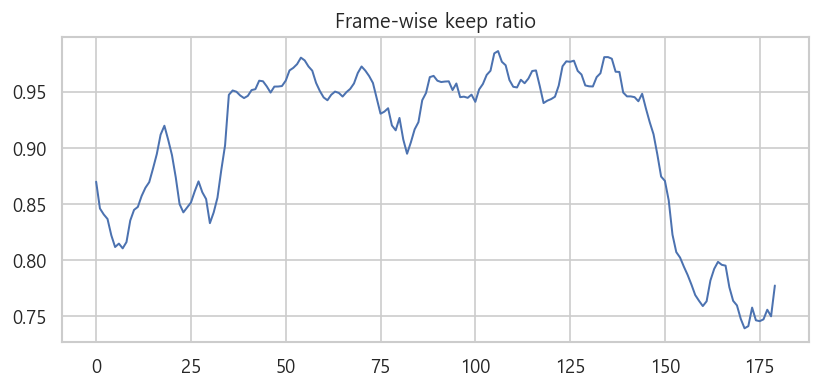

[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec03_preprocess_summary_single_ipynb.csv
[HR 해석] keep ratio는 다음 클러스터링 입력의 밀도를 결정한다.


In [61]:
with timed("section3_preprocess"):
    radar_df_clean = radar_df.copy()
    preproc_summary_df = pd.DataFrame(
        [
            {"metric": "n_raw_total", "value": int(frame_summary["raw_points"].sum())},
            {"metric": "n_clean_total", "value": int(len(radar_df_clean))},
            {"metric": "keep_ratio_global", "value": float(len(radar_df_clean) / max(frame_summary["raw_points"].sum(), 1))},
            {"metric": "keep_ratio_mean_frame", "value": float(frame_summary["kept_ratio"].mean())},
        ]
    )
ipy_display(preproc_summary_df)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(frame_summary["frame_order"], frame_summary["kept_ratio"], lw=1.2)
ax.set_title("Frame-wise keep ratio")
plt.tight_layout()
save_fig("sec03_keep_ratio")
plt.show()
save_table(preproc_summary_df, "sec03_preprocess_summary")
print("[HR 해석] keep ratio는 다음 클러스터링 입력의 밀도를 결정한다.")


## Section 4. 후보 생성 (DBSCAN / HDBSCAN)

밀도 기반 클러스터로 공간적 응집 후보를 만든다.


In [62]:
with timed("section4_cluster"):
    methods = ["dbscan"] + (["hdbscan"] if OPT["hdbscan"] else [])
    cluster_df_all, cluster_quality = s3.build_cluster_tables(radar_df_clean, methods)
    rows = []
    for alg in sorted(cluster_df_all["algorithm"].unique()):
        sub = cluster_df_all[cluster_df_all["algorithm"] == alg]
        fq = cluster_quality[cluster_quality["algorithm"] == alg]
        rows.append(
            {
                "algorithm": alg,
                "cluster_count": int(len(sub)),
                "noise_ratio": float(fq["noise_ratio"].mean()) if not fq.empty else np.nan,
                "mean_trackable_size_proxy": float(sub["n_points"].mean()),
                "mean_spread_xy": float(sub["spread_xy"].mean()),
                "mean_clusters_per_frame": float(fq["n_clusters"].mean()) if not fq.empty else np.nan,
            }
        )
    cluster_algo_summary = pd.DataFrame(rows)
    cluster_algo_summary["quality_score"] = (
        -cluster_algo_summary["noise_ratio"].fillna(1.0)
        + 0.04 * cluster_algo_summary["mean_clusters_per_frame"].fillna(0).clip(0, 30)
        - 0.001 * cluster_algo_summary["mean_spread_xy"].fillna(0)
    )
    cluster_algo_summary = cluster_algo_summary.sort_values("quality_score", ascending=False).reset_index(drop=True)
    selected_cluster_algo = str(cluster_algo_summary.iloc[0]["algorithm"])
    cluster_df_raw = cluster_df_all[cluster_df_all["algorithm"] == selected_cluster_algo].copy().reset_index(drop=True)

ipy_display(cluster_algo_summary)
save_table(cluster_algo_summary, "sec04_cluster_algo_summary")
print("selected_cluster_algo =", selected_cluster_algo)
ipy_display(cluster_df_raw.head())
print("[HR 해석] 품질 점수 상위 알고리즘을 채택해 이후 단계의 입력을 고정한다.")


[timed] section4_cluster: 13.543s


,algorithm,cluster_count,noise_ratio,mean_trackable_size_proxy,mean_spread_xy,mean_clusters_per_frame,quality_score
0,hdbscan,7561,0.224032,18.046951,0.741456,42.005556,0.975227
1,dbscan,2107,0.062720,78.592311,2.130424,11.705556,0.403371


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec04_cluster_algo_summary_single_ipynb.csv
selected_cluster_algo = hdbscan


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,spread_xy,density_proxy,mean_rcs,rcs_std,mean_vr_comp,abs_vr_comp,vr_comp_std,z_std,time_mean
0,hdbscan,00000,0,0,hdbscan:00000:0,24,16.723734,-0.831550,1.150745,16.744394,3.772177,6.360688,-18.806913,4.500692,2.889690,2.889690,0.064849,1.453561,0.0
1,hdbscan,00000,0,1,hdbscan:00000:1,55,9.496860,-1.347430,-0.244307,9.591971,3.758439,14.629844,-14.177753,9.294411,1.510404,1.510404,0.163607,0.588353,0.0
2,hdbscan,00000,0,2,hdbscan:00000:2,39,15.058232,4.475281,-0.498472,15.709186,4.385626,8.890660,-9.939492,5.581155,-0.002348,0.024633,0.052935,1.163432,0.0
3,hdbscan,00000,0,3,hdbscan:00000:3,20,19.456871,14.164801,-0.908483,24.066811,4.539105,4.405184,-0.692822,6.937578,0.027917,0.059590,0.141815,0.799502,0.0
4,hdbscan,00000,0,4,hdbscan:00000:4,18,6.429248,-4.118162,-0.027550,7.635083,2.822962,6.374024,-15.506688,10.994450,0.005667,0.011893,0.029645,0.605183,0.0


[HR 해석] 품질 점수 상위 알고리즘을 채택해 이후 단계의 입력을 고정한다.


## Section 5. 후보 억제

S1 기하, S2 그리드/속도, S3 유틸리티 게이트로 후보 수를 줄인다.


In [63]:
with timed("section5_suppress"):
    sup_full, sum_full = e2e.suppress_candidates(cluster_df_raw, mode="full")
    sup_ops, sum_ops = e2e.suppress_candidates(cluster_df_raw, mode="ops")
    suppressed_by_mode = {"full": sup_full, "ops": sup_ops}
    suppression_by_mode = {"full": sum_full, "ops": sum_ops}
    target_keep = {"ops_t20": 0.62, "ops_t18": 0.54, "ops_t15": 0.46}
    for m, frac in target_keep.items():
        d = s3.gate_top_fraction(sup_ops.copy(), keep_fraction=frac)
        if "proposal_quality_score" in d.columns:
            d = d[d["proposal_quality_score"] >= d["proposal_quality_score"].quantile(0.15)].copy()
        suppressed_by_mode[m] = d.reset_index(drop=True)
        suppression_by_mode[m] = pd.DataFrame(
            [
                {"stage": "raw_ops_base", "n_candidates": int(len(sup_ops)), "remove_ratio": 0.0, "mode": m},
                {"stage": f"extra_gate_{frac:.2f}", "n_candidates": int(len(d)), "remove_ratio": float(1 - len(d) / max(len(sup_ops), 1)), "mode": m},
            ]
        )
    suppression_summary_df = pd.concat(list(suppression_by_mode.values()), ignore_index=True)

ipy_display(suppression_summary_df.head(24))
save_table(suppression_summary_df, "sec05_suppression_summary")
frame_n = max(frame_summary["frame_id"].nunique(), 1)
burden_df = pd.DataFrame(
    [{"mode": m, "n_after": int(len(dfm)), "per_frame": float(len(dfm)) / frame_n} for m, dfm in suppressed_by_mode.items()]
).sort_values("per_frame")
ipy_display(burden_df)
save_table(burden_df, "sec05_burden_by_mode")
desc_sup, raw_h, sup_h = cluster_level_tables(cluster_df_raw, suppressed_by_mode["ops"], save_fig_fn=save_fig)
ipy_display(raw_h)
ipy_display(sup_h)
ipy_display(desc_sup)
print("[HR 해석] full은 연구용 보존, ops 계열은 운영 부담을 줄이는 방향이다.")


[timed] section5_suppress: 0.520s


,stage,n_candidates,remove_ratio,mode,topk_useful_keep_proxy
0,raw,7561,0.000000,full,0.00
1,S1_geometric,7561,0.000000,full,0.00
2,S2_temporal,7185,0.049729,full,0.00
3,S3_utility,6088,0.194816,full,0.00
4,raw,7561,0.000000,ops,0.02
5,S1_geometric,7561,0.000000,ops,0.02
6,S2_temporal,6629,0.123264,ops,0.02
7,S3_utility,4497,0.405237,ops,0.02
8,raw_ops_base,4497,0.000000,ops_t20,NaN
9,extra_gate_0.62,2370,0.472982,ops_t20,NaN


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec05_suppression_summary_single_ipynb.csv


,mode,n_after,per_frame
4,ops_t15,1758,9.766667
3,ops_t18,2064,11.466667
2,ops_t20,2370,13.166667
1,ops,4497,24.983333
0,full,6088,33.822222


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec05_burden_by_mode_single_ipynb.csv
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec05_cluster_quality_hist_single_ipynb.png


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,spread_xy,density_proxy,mean_rcs,rcs_std,mean_vr_comp,abs_vr_comp,vr_comp_std,z_std,time_mean
0,hdbscan,00000,0,0,hdbscan:00000:0,24,16.723734,-0.831550,1.150745,16.744394,3.772177,6.360688,-18.806913,4.500692,2.889690,2.889690,0.064849,1.453561,0.0
1,hdbscan,00000,0,1,hdbscan:00000:1,55,9.496860,-1.347430,-0.244307,9.591971,3.758439,14.629844,-14.177753,9.294411,1.510404,1.510404,0.163607,0.588353,0.0
2,hdbscan,00000,0,2,hdbscan:00000:2,39,15.058232,4.475281,-0.498472,15.709186,4.385626,8.890660,-9.939492,5.581155,-0.002348,0.024633,0.052935,1.163432,0.0
3,hdbscan,00000,0,3,hdbscan:00000:3,20,19.456871,14.164801,-0.908483,24.066811,4.539105,4.405184,-0.692822,6.937578,0.027917,0.059590,0.141815,0.799502,0.0
4,hdbscan,00000,0,4,hdbscan:00000:4,18,6.429248,-4.118162,-0.027550,7.635083,2.822962,6.374024,-15.506688,10.994450,0.005667,0.011893,0.029645,0.605183,0.0
5,hdbscan,00000,0,5,hdbscan:00000:5,19,29.275503,-12.447252,0.979113,31.811777,3.858086,4.923445,-1.417117,7.479192,-0.007359,0.009745,0.025614,1.742960,0.0
6,hdbscan,00000,0,6,hdbscan:00000:6,18,15.928190,-9.350979,-0.017205,18.470194,2.296128,7.835873,-3.115187,7.002433,-0.000879,0.002822,0.003501,1.068117,0.0
7,hdbscan,00001,1,0,hdbscan:00001:0,10,27.221777,2.605800,2.235157,27.346212,3.143944,3.179707,-19.246782,3.417619,2.807154,2.807154,0.057069,1.872108,-0.3


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,mean_rcs,rcs_std,mean_vr_comp,abs_vr_comp,vr_comp_std,z_std,time_mean,grid_count,proposal_quality_score,proposal_keep_flag
0,hdbscan,00001,1,3,hdbscan:00001:3,12,16.554157,-2.471586,1.079235,16.737648,...,-19.764748,3.086903,2.930000,2.930000,0.054726,1.654356,-0.666667,26,0.602563,1
1,hdbscan,00001,1,4,hdbscan:00001:4,20,14.337863,-0.270776,0.356462,14.340420,...,-20.625965,6.121262,2.925720,2.925720,0.028142,0.714524,-0.350000,27,0.645770,1
2,hdbscan,00002,2,2,hdbscan:00002:2,17,16.680450,-2.588163,0.981298,16.880049,...,-19.626081,3.012412,2.934572,2.934572,0.061582,1.804753,-1.294118,14,0.625286,1
3,hdbscan,00002,2,3,hdbscan:00002:3,10,15.440730,-0.266837,0.079750,15.443035,...,-21.699203,3.649882,2.928916,2.928916,0.018674,0.754895,-0.800000,8,0.639578,1
4,hdbscan,00002,2,4,hdbscan:00002:4,22,13.956811,-0.501093,0.451678,13.965803,...,-20.449224,6.787945,2.934850,2.934850,0.034915,0.663159,-0.863636,25,0.663115,1
5,hdbscan,00002,2,5,hdbscan:00002:5,13,30.398338,-10.043882,-1.710209,32.014660,...,-11.572770,3.039805,-0.849708,0.849708,0.105203,0.745917,-0.923077,2,0.620992,1
6,hdbscan,00002,2,7,hdbscan:00002:7,10,11.474182,-2.489938,-0.008923,11.741237,...,-19.617413,5.411063,1.828978,1.828978,0.062713,0.228481,-0.900000,28,0.616564,1
7,hdbscan,00002,2,11,hdbscan:00002:11,17,5.994259,-0.938920,-0.091296,6.067348,...,-5.014764,8.930916,1.511395,1.511395,0.012196,0.175518,-1.176471,27,0.653171,1


,count,mean,std,min,10%,50%,90%,max
n_points,4497.0,20.487214,21.100049,8.000000,9.000000,15.000000,33.000000,226.000000
spread_xy,4497.0,0.415250,0.389076,0.020110,0.090748,0.296922,0.878823,4.270748
mean_rcs,4497.0,-11.203279,9.087137,-35.000000,-22.268385,-11.192487,0.264247,14.993655
mean_vr_comp,4497.0,0.061924,0.516953,-1.997448,-0.011206,0.000931,0.008093,4.146639
vr_comp_std,4497.0,0.020918,0.047288,0.000270,0.003087,0.007391,0.040734,0.538954
density_proxy,4497.0,68.085148,51.033209,11.887269,29.168385,52.864331,123.275254,489.826448
proposal_quality_score,4497.0,0.671992,0.061439,0.595162,0.606371,0.655142,0.776651,0.864114


[HR 해석] full은 연구용 보존, ops 계열은 운영 부담을 줄이는 방향이다.


## Section 6. LiDAR corroboration + 듀얼 파이프라인

`e2e.run_branch`가 LiDAR v3(내부적으로 v2 점수 유지) 트래킹·규칙·ML·hybrid까지 수행한다. v1(`lidar_corroboration_score`) vs v2(`lidar_corroboration_score_v2`)는 **같은 파이프 출력**에서 비교한다.


In [64]:
frame_by_id = {fr["frame_id"]: fr for fr in frames}
RESULTS = {}
with timed("section6_run_branch_all_modes"):
    for m in ["full", "ops", "ops_t20", "ops_t18", "ops_t15"]:
        RESULTS[m] = e2e.run_branch(
            suppressed_by_mode[m],
            suppression_by_mode[m],
            mode=m,
            frames=frames,
            frame_by_id=frame_by_id,
            roi=ROI,
            track_gate_dist=TRACK_GATE_DIST,
            seed=SEED,
            opt=OPT,
        )

for m, R in RESULTS.items():
    print(m, "n_suppressed", len(R.cluster_df_suppressed), "n_tracked_rows", len(R.cluster_df_tracked))

R0 = RESULTS["full"]
cdf = R0.cluster_df_corr
cols_v = [c for c in ["lidar_corroboration_score", "lidar_corroboration_score_v2"] if c in cdf.columns]
if len(cols_v) >= 2:
    subc = cdf[[cols_v[0], cols_v[1]]].dropna()
    rho = float(subc.corr(method="spearman").iloc[0, 1]) if len(subc) > 2 else float("nan")
    cmp_df = pd.DataFrame({"mean_v1": [float(cdf[cols_v[0]].mean())], "mean_v2": [float(cdf[cols_v[1]].mean())], "spearman_v1_v2": [rho]})
else:
    cmp_df = pd.DataFrame([{"note": "missing v1 or v2 columns"}])
ipy_display(cmp_df)
save_table(cmp_df, "sec06_lidar_v1_v2_compare")
ipy_display(R0.cluster_df_corr.head(8))
print("[HR 해석] LiDAR는 정답 라벨이 아니라 radar-only 착오를 줄이는 보조 검증 신호다.")


[timed] section6_run_branch_all_modes: 761.486s
full n_suppressed 6088 n_tracked_rows 6088
ops n_suppressed 4497 n_tracked_rows 4497
ops_t20 n_suppressed 2370 n_tracked_rows 2370
ops_t18 n_suppressed 2064 n_tracked_rows 2064
ops_t15 n_suppressed 1758 n_tracked_rows 1758


,mean_v1,mean_v2,spearman_v1_v2
0,0.531196,0.468721,0.658509


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec06_lidar_v1_v2_compare_single_ipynb.csv


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,lidar_corroboration_score,lidar_verified,lidar_mode,lidar_min_dist_center,lidar_min_dist_extent,lidar_density_center,lidar_density_extent,lidar_multi_nn_mean_dist,lidar_overlap_proxy,lidar_corroboration_score_v2
0,hdbscan,00000,0,0,hdbscan:00000:0,24,16.723734,-0.831550,1.150745,16.744394,...,0.386622,0,lidar,2.420059,0.094906,0.000043,0.059390,2.465838,0.121612,0.418959
1,hdbscan,00000,0,1,hdbscan:00000:1,55,9.496860,-1.347430,-0.244307,9.591971,...,0.590218,1,lidar,0.063608,0.000998,0.079424,0.341347,0.066279,0.470073,0.604918
2,hdbscan,00001,1,1,hdbscan:00001:1,95,9.183059,-1.461491,-0.240686,9.298630,...,0.596986,1,lidar,0.039242,0.012480,0.085658,0.336906,0.043617,0.479803,0.607807
3,hdbscan,00001,1,2,hdbscan:00001:2,8,30.573341,-9.955719,-1.851060,32.153469,...,0.507559,1,lidar,0.624768,0.283028,0.001098,0.000086,0.650075,0.031621,0.443225
4,hdbscan,00001,1,3,hdbscan:00001:3,12,16.554157,-2.471586,1.079235,16.737648,...,0.477158,1,lidar,1.076080,0.464748,0.002066,0.000387,1.127876,0.035044,0.427734
5,hdbscan,00001,1,4,hdbscan:00001:4,20,14.337863,-0.270776,0.356462,14.340420,...,0.454204,1,lidar,1.413487,0.796937,0.000753,0.000258,1.455103,0.006716,0.405918
6,hdbscan,00001,1,10,hdbscan:00001:10,23,6.030051,-4.650162,-0.132717,7.614822,...,0.571250,1,lidar,0.182063,0.034659,0.056302,0.127410,0.205342,0.216489,0.521241
7,hdbscan,00002,2,1,hdbscan:00002:1,9,19.343611,-3.642620,1.131709,19.683596,...,0.499302,1,lidar,0.749811,0.318947,0.001731,0.000321,0.808632,0.074398,0.447780


[HR 해석] LiDAR는 정답 라벨이 아니라 radar-only 착오를 줄이는 보조 검증 신호다.


## Section 7. Tracking

baseline vs improved 요약과 temporal 분포.


In [65]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.tracking_summary_df.assign(mode=m))
    save_table(R.tracking_summary_df.assign(mode=m), f"sec07_tracking_{m}")
    ipy_display(track_level_eda(R.track_obs_selected, save_fig_fn=lambda n, mm=m: save_fig(f"{n}_{mm}")))
    trep = temporal_feature_distribution_report(R.track_obs_selected)
    ipy_display(trep)
    save_table(trep, f"sec07_temporal_stats_{m}")
print("[HR 해석] fragmentation이 낮고 track_len이 길수록 temporal 신호가 안정적이다.")


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio
0,full,528,11.530303,0.176136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,full,470,12.953191,0.114894,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec07_tracking_full_single_ipynb.csv
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec07_track_temporal_dists_full_single_ipynb.png


,count,mean,std,min,10%,50%,90%,max
track_len,6088.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
approach_score,6088.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,feature,mean,std,median,p90,nonzero_ratio
0,approach_score,0.0,0.0,0.0,0.0,0.0
1,temporal_stability_score,0.0,0.0,0.0,0.0,0.0


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec07_temporal_stats_full_single_ipynb.csv


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio
0,ops,435,10.337931,0.211494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ops,355,12.667606,0.098592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec07_tracking_ops_single_ipynb.csv
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec07_track_temporal_dists_ops_single_ipynb.png


,count,mean,std,min,10%,50%,90%,max
track_len,4497.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
approach_score,4497.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,feature,mean,std,median,p90,nonzero_ratio
0,approach_score,0.0,0.0,0.0,0.0,0.0
1,temporal_stability_score,0.0,0.0,0.0,0.0,0.0


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec07_temporal_stats_ops_single_ipynb.csv
[HR 해석] fragmentation이 낮고 track_len이 길수록 temporal 신호가 안정적이다.


## Section 8. Rule-based risk

rule v1/v2와 threshold sensitivity.


In [66]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.cluster_df_rule[["risk_score_rule_v1", "risk_score_rule_v2"]].describe())
    ipy_display(R.threshold_sensitivity_df.head(15))
    save_table(R.threshold_sensitivity_df.assign(mode=m), f"sec08_thresh_{m}")
    vc = R.cluster_df_rule["risk_label_rule_v2"].value_counts()
    print(m, "risk_label_rule_v2:\n", vc)
print("[HR 해석] high=0이면 ML/ranking 지표가 붕괴하므로 threshold sensitivity로 범위를 점검한다.")


,risk_score_rule_v1,risk_score_rule_v2
count,6088.000000,6088.000000
mean,0.169254,0.262134
std,0.054094,0.049000
min,0.002677,0.052536
25%,0.139882,0.238112
50%,0.174881,0.269055
75%,0.199670,0.295389
max,0.457842,0.429151


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,6071,17,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,5215,730,143,1.0,0.0,3.964491,0.562154
2,quantile_only_q0.92,4992,609,487,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,5114,608,366,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,5235,609,244,NaN,NaN,NaN,NaN


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec08_thresh_full_single_ipynb.csv
full risk_label_rule_v2:
 risk_label_rule_v2
low       5215
medium     730
high       143
Name: count, dtype: int64


,risk_score_rule_v1,risk_score_rule_v2
count,4497.000000,4497.000000
mean,0.177315,0.269551
std,0.050374,0.043802
min,0.006635,0.088354
25%,0.152465,0.248981
50%,0.179903,0.274306
75%,0.203421,0.297635
max,0.453302,0.408252


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,4486,11,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,3852,539,106,1.0,0.0,3.729895,0.566554
2,quantile_only_q0.92,3687,450,360,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,3777,450,270,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,3867,450,180,NaN,NaN,NaN,NaN


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec08_thresh_ops_single_ipynb.csv
ops risk_label_rule_v2:
 risk_label_rule_v2
low       3852
medium     539
high       106
Name: count, dtype: int64
[HR 해석] high=0이면 ML/ranking 지표가 붕괴하므로 threshold sensitivity로 범위를 점검한다.


## Section 9. Feature sets & anti-leakage

A/B에 blacklist·rule-like·target helper가 섞이면 assert로 중단한다.


In [67]:
R = RESULTS["ops"]
chk = assert_ab_feature_sets_clean(R.feature_set_dict)
ipy_display(chk)
ipy_display(R.feature_set_summary_df)
save_table(R.feature_set_summary_df, "sec09_feature_sets")
save_table(chk, "sec09_anti_leakage_assert")
print("[HR 해석] C 세트는 diagnostic 전용이며 honest 보고에는 쓰지 않는다.")


,feature_set,blacklist_hits,passed
0,A_strict_anti_leakage,,True
1,B_moderate_anti_leakage,,True


,feature_set,n_features,contains_leakage_core,contains_ttc,contains_range_xy,contains_abs_vr_comp,contains_rule_score_like_feature,anti_leakage_passed,sample_features
0,A_strict_anti_leakage,31,False,False,False,False,False,True,"spread_xy, density_proxy, n_points, mean_rcs, ..."
1,B_moderate_anti_leakage,37,False,False,False,False,False,True,"spread_xy, density_proxy, n_points, mean_rcs, ..."
2,C_diagnostic_leakage,39,True,False,False,False,True,False,"spread_xy, density_proxy, n_points, mean_rcs, ..."


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec09_feature_sets_single_ipynb.csv
[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec09_anti_leakage_assert_single_ipynb.csv
[HR 해석] C 세트는 diagnostic 전용이며 honest 보고에는 쓰지 않는다.


## Section 10. Split 설계

random은 overall 진단용, 최종 해석은 honest split만.


In [68]:
R = RESULTS["ops"]
ipy_display(R.split_summary_df)
save_table(R.split_summary_df, "sec10_splits")
for _, r in R.split_summary_df.iterrows():
    print(r["split"], "n_test", r["n_test"], "test_high", r["test_high"])
print("[HR 해석] random은 동일 프레임 상관으로 낙관될 수 있어 결론에 쓰지 않는다.")


,split,n_train,n_test,train_high,test_high
0,random,3373,1124,81,25
1,group_frame,3398,1099,85,21
2,time,3361,1136,82,24
3,contiguous_block,2986,1511,76,30


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec10_splits_single_ipynb.csv
random n_test 1124 test_high 25
group_frame n_test 1099 test_high 21
time n_test 1136 test_high 24
contiguous_block n_test 1511 test_high 30
[HR 해석] random은 동일 프레임 상관으로 낙관될 수 있어 결론에 쓰지 않는다.


## Section 11. ML refinement

`best_model_summary_any_split` vs `best_model_summary_honest_only`를 분리한다.


In [69]:
best_any_rows = []
best_hon_rows = []
for m, R in RESULTS.items():
    exp = R.experiment_results_df.copy()
    exp = exp[exp["task"] == "classification"]
    exp = exp.merge(R.split_summary_df[["split", "n_test", "test_high"]], on="split", how="left")
    ipy_display(exp.head(25))
    save_table(exp, f"sec11_experiments_{m}")
    ba = pick_best_any_split(exp)
    bh = pick_best_honest_only(exp)
    if len(ba):
        best_any_rows.append({"pipeline_mode": m, **{k: ba.get(k) for k in ["model", "feature_set", "split", "macro_f1", "high_recall", "ranking_ap"]}})
    best_hon_rows.append({"pipeline_mode": m, **{k: bh.get(k) for k in ["model", "feature_set", "split", "macro_f1", "high_recall", "ranking_ap"]}})

best_model_summary_any_split = pd.DataFrame(best_any_rows)
best_model_summary_honest_only = pd.DataFrame(best_hon_rows)
ipy_display(best_model_summary_any_split)
ipy_display(best_model_summary_honest_only)
save_table(best_model_summary_any_split, "sec11_best_any_split")
save_table(best_model_summary_honest_only, "sec11_best_honest_only")
print("[HR 해석] any_split 행에 random이 보일 수 있다. 최종 요약은 honest_only만 사용한다.")


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,n_test,test_high
0,classification,logreg,A_strict_anti_leakage,random,0.905536,0.720930,0.575441,1.0,0.185393,-0.098017,NaN,NaN,1522,43
1,classification,rf,A_strict_anti_leakage,random,0.940042,0.790698,0.593335,1.0,0.191011,0.059958,NaN,NaN,1522,43
2,classification,svm_rbf,A_strict_anti_leakage,random,0.905536,0.720930,0.496849,1.0,0.185393,0.036533,NaN,NaN,1522,43
3,classification,hgb,A_strict_anti_leakage,random,0.962402,0.883721,0.659677,1.0,0.219101,0.037598,NaN,NaN,1522,43
4,classification,logreg,A_strict_anti_leakage,group_frame,0.917697,0.787879,0.529878,1.0,0.644444,-0.097206,NaN,NaN,1539,33
5,classification,rf,A_strict_anti_leakage,group_frame,0.967079,0.878788,0.553846,1.0,0.644444,0.032921,NaN,NaN,1539,33
6,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.950618,0.848485,0.472348,1.0,0.644444,-0.003018,NaN,NaN,1539,33
7,classification,hgb,A_strict_anti_leakage,group_frame,0.984043,0.939394,0.587849,1.0,0.688889,0.015957,NaN,NaN,1539,33
8,classification,logreg,A_strict_anti_leakage,time,0.694502,0.275000,0.642061,0.8,0.517241,0.176551,NaN,NaN,1528,40
9,classification,rf,A_strict_anti_leakage,time,0.690920,0.250000,0.673098,0.9,0.379310,0.309080,NaN,NaN,1528,40


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec11_experiments_full_single_ipynb.csv


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,n_test,test_high
0,classification,logreg,A_strict_anti_leakage,random,0.844647,0.640000,0.545377,0.8,0.117978,-0.038272,NaN,NaN,1124,25
1,classification,rf,A_strict_anti_leakage,random,0.902949,0.680000,0.503283,1.0,0.095506,0.097051,NaN,NaN,1124,25
2,classification,svm_rbf,A_strict_anti_leakage,random,0.957424,0.880000,0.514808,1.0,0.129213,0.008923,NaN,NaN,1124,25
3,classification,hgb,A_strict_anti_leakage,random,0.943310,0.800000,0.567416,1.0,0.112360,0.056690,NaN,NaN,1124,25
4,classification,logreg,A_strict_anti_leakage,group_frame,0.923610,0.809524,0.527063,1.0,0.422222,-0.162484,NaN,NaN,1099,21
5,classification,rf,A_strict_anti_leakage,group_frame,0.974537,0.904762,0.411484,1.0,0.422222,0.025463,NaN,NaN,1099,21
6,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.975727,0.952381,0.435269,1.0,0.466667,-0.007730,NaN,NaN,1099,21
7,classification,hgb,A_strict_anti_leakage,group_frame,0.987573,0.952381,0.453802,1.0,0.444444,0.012427,NaN,NaN,1099,21
8,classification,logreg,A_strict_anti_leakage,time,0.725374,0.541667,0.579886,0.7,1.185185,0.094049,NaN,NaN,1136,24
9,classification,rf,A_strict_anti_leakage,time,0.494662,0.000000,0.433042,0.5,0.000000,0.505338,NaN,NaN,1136,24


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec11_experiments_ops_single_ipynb.csv


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,n_test,test_high
0,classification,logreg,A_strict_anti_leakage,random,0.683219,0.230769,0.520460,0.5,0.018182,0.062490,NaN,NaN,592,13
1,classification,rf,A_strict_anti_leakage,random,0.933491,0.769231,0.493717,1.0,0.060606,0.066509,NaN,NaN,592,13
2,classification,svm_rbf,A_strict_anti_leakage,random,0.933491,0.769231,0.491810,1.0,0.060606,0.006774,NaN,NaN,592,13
3,classification,hgb,A_strict_anti_leakage,random,0.957471,0.846154,0.521430,1.0,0.066667,0.042529,NaN,NaN,592,13
4,classification,logreg,A_strict_anti_leakage,group_frame,0.847600,0.583333,0.585029,0.7,0.177778,-0.143204,NaN,NaN,635,12
5,classification,rf,A_strict_anti_leakage,group_frame,0.898400,0.666667,0.475531,0.8,0.177778,0.101600,NaN,NaN,635,12
6,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.812992,0.500000,0.497784,0.7,0.155556,0.149537,NaN,NaN,635,12
7,classification,hgb,A_strict_anti_leakage,group_frame,0.861233,0.666667,0.591805,0.8,0.222222,0.138767,NaN,NaN,635,12
8,classification,logreg,A_strict_anti_leakage,time,0.574801,0.222222,0.369496,0.1,0.555556,0.202426,NaN,NaN,598,9
9,classification,rf,A_strict_anti_leakage,time,0.495784,0.000000,0.376133,0.2,0.037037,0.504216,NaN,NaN,598,9


...

,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,n_test,test_high
0,classification,logreg,A_strict_anti_leakage,random,0.861910,0.666667,0.294222,0.5,0.033113,0.048651,NaN,NaN,440,6
1,classification,rf,A_strict_anti_leakage,random,0.861910,0.666667,0.370457,0.5,0.033113,0.138090,NaN,NaN,440,6
2,classification,svm_rbf,A_strict_anti_leakage,random,0.915515,0.833333,0.315208,0.5,0.039735,0.056678,NaN,NaN,440,6
3,classification,hgb,A_strict_anti_leakage,random,0.621560,0.166667,0.348912,0.5,0.013245,0.378440,NaN,NaN,440,6
4,classification,logreg,A_strict_anti_leakage,group_frame,0.862008,1.000000,0.315661,0.4,0.155556,0.049891,NaN,NaN,466,4
5,classification,rf,A_strict_anti_leakage,group_frame,0.943903,1.000000,0.380075,0.4,0.111111,0.056097,NaN,NaN,466,4
6,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.943903,1.000000,0.326531,0.4,0.111111,0.009247,NaN,NaN,466,4
7,classification,hgb,A_strict_anti_leakage,group_frame,0.943903,1.000000,0.413711,0.4,0.111111,0.056097,NaN,NaN,466,4
8,classification,logreg,A_strict_anti_leakage,time,0.499431,0.000000,0.165412,0.0,0.000000,0.397640,NaN,NaN,440,1
9,classification,rf,A_strict_anti_leakage,time,0.497717,0.000000,0.391447,0.0,0.111111,0.502283,NaN,NaN,440,1


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec11_experiments_ops_t15_single_ipynb.csv


,pipeline_mode,model,feature_set,split,macro_f1,high_recall,ranking_ap
0,full,hgb,B_moderate_anti_leakage,random,0.981846,0.953488,0.846852
1,ops,logreg,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.750812
2,ops_t20,logreg,B_moderate_anti_leakage,group_frame,0.953744,0.833333,0.828397
3,ops_t18,logreg,B_moderate_anti_leakage,group_frame,0.975733,0.909091,0.684777
4,ops_t15,hgb,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.551982


,pipeline_mode,model,feature_set,split,macro_f1,high_recall,ranking_ap
0,full,hgb,B_moderate_anti_leakage,group_frame,0.984043,0.939394,0.819050
1,ops,logreg,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.750812
2,ops_t20,logreg,B_moderate_anti_leakage,group_frame,0.953744,0.833333,0.828397
3,ops_t18,logreg,B_moderate_anti_leakage,group_frame,0.975733,0.909091,0.684777
4,ops_t15,hgb,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.551982


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec11_best_any_split_single_ipynb.csv
[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec11_best_honest_only_single_ipynb.csv
[HR 해석] any_split 행에 random이 보일 수 있다. 최종 요약은 honest_only만 사용한다.


## Section 12. Calibration

raw 대비 Brier/ECE가 나빠지면 보정 미적용(e2e 내부 정책).


,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.001428,0.001747,0.477405,1.0,0.018843,0.017544,0.977258
1,platt_cv,0.001703,0.006008,0.814324,1.0,0.010396,0.000650,0.001949
2,isotonic_cv,0.001758,0.004448,0.655248,1.0,0.016244,0.016244,0.898635


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec12_cal_full_single_ipynb.csv
full calibration_used False method raw
saturation_raw {'sat_gt_0.99': 0.018843404808317088, 'sat_gt_0.999': 0.017543859649122806, 'sat_lt_1e-3': 0.9772579597141} saturation_selected {'sat_gt_0.99': 0.018843404808317088, 'sat_gt_0.999': 0.017543859649122806, 'sat_lt_1e-3': 0.9772579597141}
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec12_rel_full_single_ipynb.png


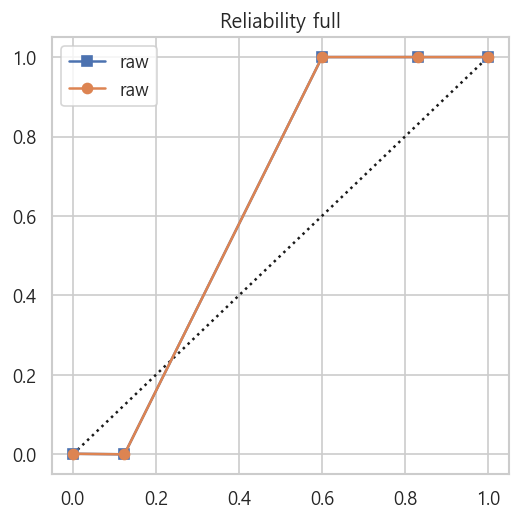

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.000151,0.001274,0.750812,1.0,0.011829,0.007279,0.924477
1,platt_cv,0.000641,0.005308,0.668783,1.0,0.006369,0.002730,0.479527
2,isotonic_cv,0.000740,0.003823,0.439082,1.0,0.008189,0.008189,0.941765


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec12_cal_ops_single_ipynb.csv
ops calibration_used False method raw
saturation_raw {'sat_gt_0.99': 0.011828935395814377, 'sat_gt_0.999': 0.007279344858962694, 'sat_lt_1e-3': 0.924476797088262} saturation_selected {'sat_gt_0.99': 0.011828935395814377, 'sat_gt_0.999': 0.007279344858962694, 'sat_lt_1e-3': 0.924476797088262}
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec12_rel_ops_single_ipynb.png


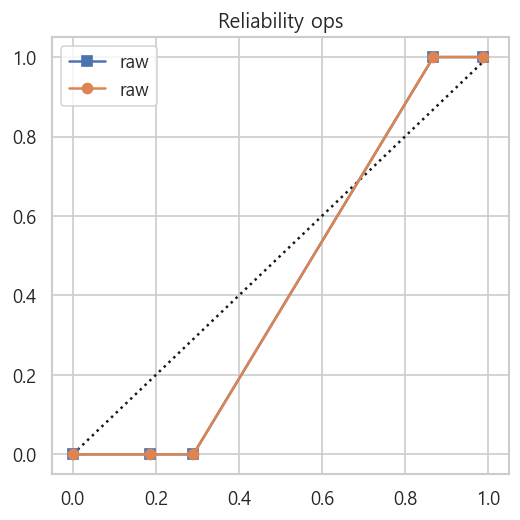

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.002337,0.008280,0.828397,1.0,0.009449,0.007874,0.784252
1,platt_cv,0.005025,0.015505,0.757807,1.0,0.000000,0.000000,0.026772
2,isotonic_cv,0.004166,0.014115,0.738482,1.0,0.009449,0.009449,0.667717


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec12_cal_ops_t20_single_ipynb.csv
ops_t20 calibration_used False method raw
saturation_raw {'sat_gt_0.99': 0.009448818897637795, 'sat_gt_0.999': 0.007874015748031496, 'sat_lt_1e-3': 0.784251968503937} saturation_selected {'sat_gt_0.99': 0.009448818897637795, 'sat_gt_0.999': 0.007874015748031496, 'sat_lt_1e-3': 0.784251968503937}
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec12_rel_ops_t20_single_ipynb.png


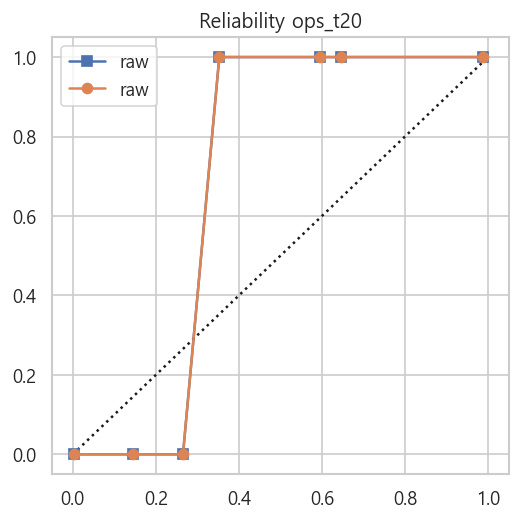

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.002696,0.003763,0.684777,1.0,0.008977,0.003591,0.833034
1,platt_cv,0.005041,0.013338,0.641716,1.0,0.000000,0.000000,0.039497
2,isotonic_cv,0.004070,0.008633,0.491601,1.0,0.005386,0.005386,0.877917


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec12_cal_ops_t18_single_ipynb.csv
ops_t18 calibration_used False method raw
saturation_raw {'sat_gt_0.99': 0.008976660682226212, 'sat_gt_0.999': 0.003590664272890485, 'sat_lt_1e-3': 0.8330341113105925} saturation_selected {'sat_gt_0.99': 0.008976660682226212, 'sat_gt_0.999': 0.003590664272890485, 'sat_lt_1e-3': 0.8330341113105925}
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec12_rel_ops_t18_single_ipynb.png


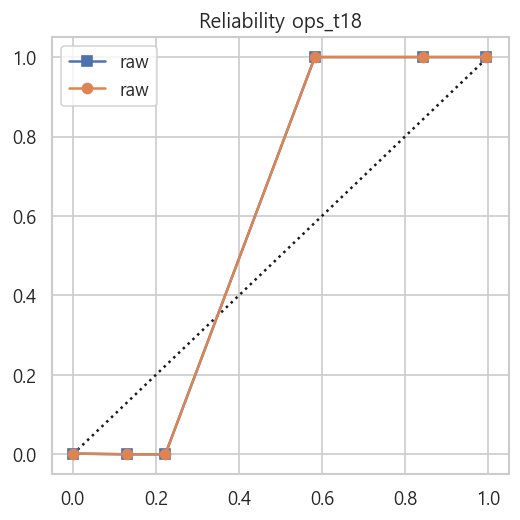

,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,1.221058e-08,0.000007,0.379593,0.4,0.008584,0.008584,0.989270
1,platt_cv,5.016780e-04,0.006183,0.560218,0.4,0.000000,0.000000,0.000000
2,isotonic_cv,5.247066e-04,0.001796,0.234773,0.4,0.008584,0.008584,0.984979


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec12_cal_ops_t15_single_ipynb.csv
ops_t15 calibration_used False method raw
saturation_raw {'sat_gt_0.99': 0.008583690987124463, 'sat_gt_0.999': 0.008583690987124463, 'sat_lt_1e-3': 0.9892703862660944} saturation_selected {'sat_gt_0.99': 0.008583690987124463, 'sat_gt_0.999': 0.008583690987124463, 'sat_lt_1e-3': 0.9892703862660944}
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec12_rel_ops_t15_single_ipynb.png


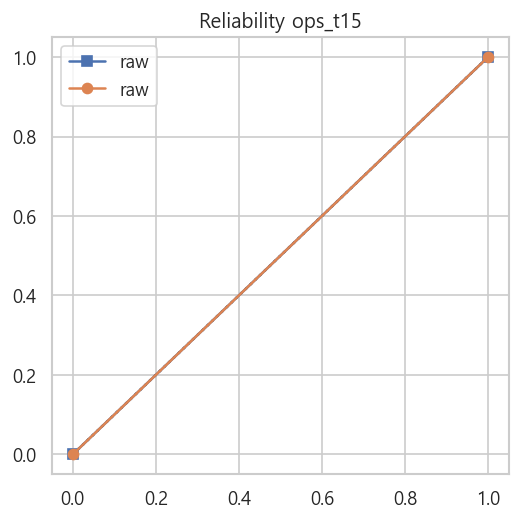

[HR 해석] 보정은 항상 이득이 아니므로 raw fallback을 허용한다.


In [70]:
from sklearn.calibration import calibration_curve

for m, R in RESULTS.items():
    cb = R.calibration_bundle
    ipy_display(cb["calibration_compare_df"])
    save_table(cb["calibration_compare_df"], f"sec12_cal_{m}")
    print(m, "calibration_used", cb["calibration_used"], "method", cb["selected_calibration_method"])
    print("saturation_raw", cb.get("saturation_raw"), "saturation_selected", cb.get("saturation_selected"))
    tr, te = R.split_dict[str(R.honest_best_row["split"])]
    y = (R.cluster_df_rule["risk_label_rule_v2"] == "high").astype(int).to_numpy()
    yte = y[te]
    p_raw, p_sel = cb["p_raw"], cb["p_selected"]
    pr, pp = calibration_curve(yte, p_raw, n_bins=10, strategy="uniform")
    pr2, pp2 = calibration_curve(yte, p_sel, n_bins=10, strategy="uniform")
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.plot([0, 1], [0, 1], "k:")
    ax.plot(pp, pr, "s-", label="raw")
    ax.plot(pp2, pr2, "o-", label=str(cb["selected_calibration_method"]))
    ax.legend()
    ax.set_title(f"Reliability {m}")
    plt.tight_layout()
    save_fig(f"sec12_rel_{m}")
    plt.show()
print("[HR 해석] 보정은 항상 이득이 아니므로 raw fallback을 허용한다.")


## Section 13. Final hybrid score

rule vs hybrid, sensitivity sweep.


In [71]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.hybrid_vs_rule_df.assign(mode=m))
    ipy_display(R.hybrid_sensitivity_df.assign(mode=m))
    save_table(R.hybrid_vs_rule_df.assign(mode=m), f"sec13_hybrid_{m}")
    comp = R.cluster_df_final[["risk_score_rule_v2", "score_final_stage4"]].describe()
    ipy_display(comp)
print("[HR 해석] hybrid는 부담·불확실성·설명·운영 포인트 조정에 초점을 둔다.")


,topk,overlap,rule_only_mean_score,hybrid_mean_score,mode
0,30,0.4,0.262134,0.35082,full


,W_LIDAR,W_TEMPORAL,W_RELIABILITY,W_QUALITY,W_UNCERTAINTY,ranking_ap,p10,burden_per_frame,mode
0,0.10,0.10,0.08,0.06,0.18,0.672588,1.0,33.822222,full
1,0.12,0.10,0.10,0.08,0.20,0.671561,1.0,33.822222,full
2,0.08,0.14,0.10,0.08,0.22,0.558312,1.0,33.822222,full


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec13_hybrid_full_single_ipynb.csv


,risk_score_rule_v2,score_final_stage4
count,6088.000000,6088.000000
mean,0.262134,0.350820
std,0.049000,0.060019
min,0.052536,0.095529
25%,0.238112,0.321440
50%,0.269055,0.359515
75%,0.295389,0.390856
max,0.429151,0.629734


,topk,overlap,rule_only_mean_score,hybrid_mean_score,mode
0,30,0.633333,0.269551,0.361183,ops


,W_LIDAR,W_TEMPORAL,W_RELIABILITY,W_QUALITY,W_UNCERTAINTY,ranking_ap,p10,burden_per_frame,mode
0,0.10,0.10,0.08,0.06,0.18,0.629400,1.0,25.122905,ops
1,0.12,0.10,0.10,0.08,0.20,0.627540,1.0,25.122905,ops
2,0.08,0.14,0.10,0.08,0.22,0.498708,1.0,25.122905,ops


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec13_hybrid_ops_single_ipynb.csv


,risk_score_rule_v2,score_final_stage4
count,4497.000000,4497.000000
mean,0.269551,0.361183
std,0.043802,0.054177
min,0.088354,0.131830
25%,0.248981,0.334866
50%,0.274306,0.367458
75%,0.297635,0.396859
max,0.408252,0.615423


[HR 해석] hybrid는 부담·불확실성·설명·운영 포인트 조정에 초점을 둔다.


## Section 14. Ranking evaluation

top-k 및 연관 지표.


In [72]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.ranking_summary_df.assign(mode=m))
    save_table(R.ranking_summary_df.assign(mode=m), f"sec14_rank_{m}")
print("[HR 해석] precision@k가 운영에서 직접 연결되는 지표다.")


,metric,value,mode
0,precision@5_hard,1.000000,full
1,precision@10_hard,1.000000,full
2,recall@10_hard,0.069930,full
3,ap_soft,0.671561,full
4,map,0.671561,full
5,mrr,1.000000,full
6,ndcg@10,1.000000,full
7,track_ap,0.741134,full
8,window10_hit_rate,0.722222,full
9,window20_hit_rate,0.777778,full


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec14_rank_full_single_ipynb.csv


,metric,value,mode
0,precision@5_hard,1.000000,ops
1,precision@10_hard,1.000000,ops
2,recall@10_hard,0.094340,ops
3,ap_soft,0.627540,ops
4,map,0.627540,ops
5,mrr,1.000000,ops
6,ndcg@10,1.000000,ops
7,track_ap,0.854661,ops
8,window10_hit_rate,0.555556,ops
9,window20_hit_rate,0.666667,ops


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec14_rank_ops_single_ipynb.csv
[HR 해석] precision@k가 운영에서 직접 연결되는 지표다.


## Section 15. Ablation

rule_only가 강해도 숨기지 않는다.


In [73]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.ablation_results_df.assign(mode=m))
    save_table(R.ablation_results_df.assign(mode=m), f"sec15_ablation_{m}")
print("[HR 해석] rule_only가 hybrid보다 나을 수 있다. hybrid 가치는 다른 축에서 평가한다.")


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,mode
0,full_model,0.637409,0.839161,0.671561,1.0,2.033333,full
1,rule_only,0.703361,1.000000,1.000000,1.0,2.033333,full
2,no_lidar,0.631639,0.825175,0.650869,1.0,2.033333,full
3,no_tracking_features,0.685119,0.909091,0.787865,1.0,2.033333,full
4,no_calibration,0.680864,0.916084,0.804568,1.0,2.033333,full
5,ml_only,0.015300,1.000000,0.142888,1.0,33.822222,full
6,rule_plus_ml_hybrid,0.643776,0.951049,0.766925,1.0,2.033333,full


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec15_ablation_full_single_ipynb.csv


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,mode
0,full_model,0.659164,0.971698,0.627540,1.0,1.508380,ops
1,rule_only,0.704220,1.000000,1.000000,1.0,1.508380,ops
2,no_lidar,0.646483,0.952830,0.597490,1.0,1.508380,ops
3,no_tracking_features,0.708929,1.000000,0.758543,1.0,1.508380,ops
4,no_calibration,0.685505,0.981132,0.814515,1.0,1.508380,ops
5,ml_only,0.015352,1.000000,0.134064,1.0,25.122905,ops
6,rule_plus_ml_hybrid,0.661585,1.000000,0.829236,1.0,1.508380,ops


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec15_ablation_ops_single_ipynb.csv
[HR 해석] rule_only가 hybrid보다 나을 수 있다. hybrid 가치는 다른 축에서 평가한다.


## Section 16. Runtime

단계별 wall-clock.


In [74]:
rt = pd.DataFrame(runtime_records).sort_values("sec", ascending=False)
ipy_display(rt)
save_table(rt, "sec16_runtime")
print("Top slow:", rt.head(3)["stage"].tolist())
print("[HR 해석] 병목은 주로 run_branch 내부(클러스터·트래킹·ML)이다.")


,stage,sec
4,section6_run_branch_all_modes,761.485927
2,section4_cluster,13.543388
0,section2_load,0.895201
3,section5_suppress,0.520112
1,section3_preprocess,0.009921


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec16_runtime_single_ipynb.csv
Top slow: ['section6_run_branch_all_modes', 'section4_cluster', 'section2_load']
[HR 해석] 병목은 주로 run_branch 내부(클러스터·트래킹·ML)이다.


## Section 17. Explainability

top / hard case 테이블.


In [75]:
for m in ("full", "ops"):
    R = RESULTS[m]
    ipy_display(R.top_candidate_table.head(12))
    ipy_display(R.hard_case_table.head(12))
    save_table(R.top_candidate_table, f"sec17_top_{m}")
    save_table(R.hard_case_table, f"sec17_hard_{m}")
print("[HR 해석] hard case는 모델 한계와 개선 우선순위를 드러낸다.")


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00118:0,234,0.629734,high,0.882413,0.261303,33,0.0,0.712092,0.607895,"근접성:0.89, LiDAR 정합:0.61, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.442, 보정신뢰=0.882, 불확실성=0.261."
1,hdbscan:00117:0,234,0.616541,high,0.881309,0.263755,33,0.0,0.712092,0.561219,"근접성:0.88, LiDAR 정합:0.56, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.434, 보정신뢰=0.881, 불확실성=0.264."
2,hdbscan:00113:2,234,0.613644,high,0.880629,0.265266,33,0.0,0.712092,0.511728,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.422, 보정신뢰=0.881, 불확실성=0.265."
3,hdbscan:00109:2,234,0.607080,high,0.880038,0.266568,33,0.0,0.712092,0.521178,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.48",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.404, 보정신뢰=0.880, 불확실성=0.267."
4,hdbscan:00096:5,234,0.606376,high,0.879811,0.267086,33,0.0,0.712092,0.528962,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.406, 보정신뢰=0.880, 불확실성=0.267."
5,hdbscan:00097:6,234,0.605160,high,0.879687,0.267360,33,0.0,0.712092,0.527624,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.401, 보정신뢰=0.880, 불확실성=0.267."
6,hdbscan:00093:3,234,0.602352,high,0.879384,0.268034,33,0.0,0.712092,0.529643,"근접성:0.87, LiDAR 정합:0.53, 운동 이상:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.406, 보정신뢰=0.879, 불확실성=0.268."
7,hdbscan:00120:0,234,0.594182,high,0.879731,0.267263,33,0.0,0.712092,0.497488,"근접성:0.88, LiDAR 정합:0.50, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.427, 보정신뢰=0.880, 불확실성=0.267."
8,hdbscan:00100:20,248,0.577861,high,0.882942,0.260125,11,0.0,0.817537,0.478159,"근접성:0.90, LiDAR 정합:0.48, 운동 이상:0.34",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.376, 보정신뢰=0.883, 불확실성=0.260."
9,hdbscan:00012:4,1,0.568508,high,0.875749,0.276109,36,0.0,0.658020,0.610494,"근접성:0.80, LiDAR 정합:0.61, 운동 이상:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.341, 보정신뢰=0.876, 불확실성=0.276."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4,hard_tmp,case_type
0,hdbscan,00001,1,10,hdbscan:00001:10,23,6.030051,-4.650162,-0.132717,7.614822,...,0.0,0.314178,0.062549,0.044286,0.031418,0.045499,0.1,0.397930,0,medium_but_persistent
1,hdbscan,00002,2,19,hdbscan:00002:19,17,4.506492,-4.437491,-0.154063,6.324539,...,0.0,0.316943,0.060703,0.032810,0.031694,0.048483,0.1,0.390633,0,medium_but_persistent
2,hdbscan,00003,3,2,hdbscan:00003:2,9,11.409592,1.454494,-0.182172,11.501927,...,0.0,0.331580,0.054172,0.021301,0.033158,0.049092,0.1,0.389303,0,medium_but_persistent
3,hdbscan,00003,3,19,hdbscan:00003:19,16,3.790225,-1.932908,-0.476325,4.254637,...,0.0,0.330268,0.062686,0.048492,0.033027,0.046051,0.1,0.420523,0,medium_but_persistent
4,hdbscan,00003,3,29,hdbscan:00003:29,20,4.449681,-4.491398,-0.166724,6.322367,...,0.0,0.316651,0.060502,0.032810,0.031665,0.050560,0.1,0.392187,0,medium_but_persistent
5,hdbscan,00003,3,31,hdbscan:00003:31,12,8.300339,-0.685513,-0.321639,8.328598,...,0.0,0.320857,0.065456,0.063110,0.032086,0.053911,0.1,0.435419,0,medium_but_persistent
6,hdbscan,00003,3,33,hdbscan:00003:33,36,6.613649,0.018519,-0.463448,6.613675,...,0.0,0.320242,0.059233,0.077660,0.032024,0.060745,0.1,0.449905,0,medium_but_persistent
7,hdbscan,00004,4,24,hdbscan:00004:24,14,8.038463,-2.448786,0.041961,8.403180,...,0.0,0.332223,0.057365,0.019744,0.033222,0.051968,0.1,0.394522,0,medium_but_persistent
8,hdbscan,00004,4,25,hdbscan:00004:25,11,9.316492,-2.895012,-0.473972,9.755927,...,0.0,0.313378,0.056458,0.032764,0.031338,0.054344,0.1,0.388282,0,medium_but_persistent
9,hdbscan,00004,4,28,hdbscan:00004:28,21,3.723038,-2.020706,-0.493190,4.236067,...,0.0,0.329884,0.062423,0.048492,0.032988,0.048995,0.1,0.422782,0,medium_but_persistent


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec17_top_full_single_ipynb.csv
[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec17_hard_full_single_ipynb.csv


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00116:0,172,0.615423,high,0.886840,0.251464,30,0.0,0.868005,0.555245,"근접성:0.89, LiDAR 정합:0.56, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.423, 보정신뢰=0.887, 불확실성=0.251."
1,hdbscan:00115:0,172,0.615273,high,0.886613,0.251969,30,0.0,0.868005,0.540991,"근접성:0.89, LiDAR 정합:0.54, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.420, 보정신뢰=0.887, 불확실성=0.252."
2,hdbscan:00112:2,172,0.612751,high,0.886089,0.253119,30,0.0,0.868005,0.509262,"근접성:0.89, LiDAR 정합:0.51, 접근/시간여유:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.410, 보정신뢰=0.886, 불확실성=0.253."
3,hdbscan:00114:2,172,0.611242,high,0.886086,0.253139,30,0.0,0.868005,0.519083,"근접성:0.89, LiDAR 정합:0.52, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.416, 보정신뢰=0.886, 불확실성=0.253."
4,hdbscan:00096:5,172,0.605599,high,0.885374,0.254679,30,0.0,0.868005,0.528962,"근접성:0.89, LiDAR 정합:0.53, 접근/시간여유:0.37",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.397, 보정신뢰=0.885, 불확실성=0.255."
5,hdbscan:00094:3,172,0.604534,high,0.885026,0.255467,30,0.0,0.868005,0.514613,"근접성:0.88, LiDAR 정합:0.51, 접근/시간여유:0.39",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.398, 보정신뢰=0.885, 불확실성=0.255."
6,hdbscan:00120:0,172,0.593608,high,0.885371,0.254728,30,0.0,0.868005,0.497488,"근접성:0.88, LiDAR 정합:0.50, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.418, 보정신뢰=0.885, 불확실성=0.255."
7,hdbscan:00099:6,172,0.586808,high,0.880241,0.263693,30,0.0,0.868005,0.488215,"근접성:0.90, LiDAR 정합:0.49, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.370, 보정신뢰=0.880, 불확실성=0.264."
8,hdbscan:00013:2,22,0.565420,high,0.874832,0.275704,29,0.0,0.724478,0.607697,"근접성:0.80, LiDAR 정합:0.61, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.337, 보정신뢰=0.875, 불확실성=0.276."
9,hdbscan:00010:8,22,0.558370,high,0.867594,0.286130,29,0.0,0.724478,0.616255,"근접성:0.79, LiDAR 정합:0.62, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.332, 보정신뢰=0.868, 불확실성=0.286."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4,hard_tmp,case_type
0,hdbscan,00003,3,2,hdbscan:00003:2,9,11.409592,1.454494,-0.182172,11.501927,...,0.0,0.331580,0.054172,0.034868,0.033158,0.048987,0.1,0.402765,0,medium_but_persistent
1,hdbscan,00004,4,2,hdbscan:00004:2,9,11.311281,1.267381,-0.180891,11.382062,...,0.0,0.332750,0.054220,0.034868,0.033275,0.048987,0.1,0.404100,0,medium_but_persistent
2,hdbscan,00004,4,24,hdbscan:00004:24,14,8.038463,-2.448786,0.041961,8.403180,...,0.0,0.332223,0.057365,0.053792,0.033222,0.051794,0.1,0.428396,0,medium_but_persistent
3,hdbscan,00004,4,28,hdbscan:00004:28,21,3.723038,-2.020706,-0.493190,4.236067,...,0.0,0.329884,0.062423,0.025539,0.032988,0.048858,0.1,0.399692,0,medium_but_persistent
4,hdbscan,00005,5,20,hdbscan:00005:20,25,3.489276,-1.883031,-0.541588,3.964953,...,0.0,0.330203,0.062086,0.025539,0.033020,0.050091,0.1,0.400939,0,medium_but_persistent
5,hdbscan,00005,5,35,hdbscan:00005:35,13,8.033880,-2.609080,0.053654,8.446924,...,0.0,0.331730,0.057353,0.053792,0.033173,0.050609,0.1,0.426656,0,medium_but_persistent
6,hdbscan,00006,6,11,hdbscan:00006:11,27,3.357191,-1.791310,-0.509389,3.805197,...,0.0,0.331450,0.062379,0.025539,0.033145,0.048958,0.1,0.401471,0,medium_but_persistent
7,hdbscan,00007,7,30,hdbscan:00007:30,42,8.465387,-3.175342,-0.182881,9.041327,...,0.0,0.322915,0.062872,0.049804,0.032291,0.051384,0.1,0.419267,0,medium_but_persistent
8,hdbscan,00008,8,13,hdbscan:00008:13,11,7.651906,-0.904183,-0.924065,7.705142,...,0.0,0.321483,0.064575,0.025539,0.032148,0.047914,0.1,0.391659,0,medium_but_persistent
9,hdbscan,00008,8,21,hdbscan:00008:21,27,3.181148,-2.226798,-0.519525,3.883082,...,0.0,0.331510,0.062687,0.033017,0.033151,0.050522,0.1,0.410887,0,medium_but_persistent


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec17_top_ops_single_ipynb.csv
[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec17_hard_ops_single_ipynb.csv
[HR 해석] hard case는 모델 한계와 개선 우선순위를 드러낸다.


## Section 18. Temporal effectiveness

permutation importance 및 rank shift 예시.


In [76]:
for m in ("full", "ops"):
    R = RESULTS[m]
    imp = e2e.temporal_importance_proxy(R.cluster_df_final, R.honest_feature_cols, SEED)
    ipy_display(imp.assign(mode=m))
    save_table(imp.assign(mode=m), f"sec18_temporal_imp_{m}")

Rops = RESULTS["ops"]
d = Rops.cluster_df_final.copy()
d["_rk_rule"] = d["risk_score_rule_v2"].rank(ascending=False, method="first")
d["_rk_hyb"] = d["score_final_stage4"].rank(ascending=False, method="first")
shift = d.nsmallest(15, "_rk_hyb")[["cluster_uid", "_rk_rule", "_rk_hyb", "approach_score", "closing_consistency_score"]]
ipy_display(shift)
save_table(shift, "sec18_rank_shift_examples")
print("[HR 해석] temporal 기여가 약하면 importance와 rank shift가 작게 나온다.")


,temporal_feature_importance_sum,n_temporal_cols_used,mode
0,0.000164,15,full


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec18_temporal_imp_full_single_ipynb.csv


,temporal_feature_importance_sum,n_temporal_cols_used,mode
0,0.0,15,ops


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec18_temporal_imp_ops_single_ipynb.csv


,cluster_uid,_rk_rule,_rk_hyb,approach_score,closing_consistency_score
2587,hdbscan:00116:0,3.0,1.0,0.0,0.868005
2565,hdbscan:00115:0,4.0,2.0,0.0,0.868005
2499,hdbscan:00112:2,6.0,3.0,0.0,0.868005
2541,hdbscan:00114:2,7.0,4.0,0.0,0.868005
2302,hdbscan:00096:5,11.0,5.0,0.0,0.868005
2273,hdbscan:00094:3,16.0,6.0,0.0,0.868005
2661,hdbscan:00120:0,12.0,7.0,0.0,0.868005
2337,hdbscan:00099:6,26.0,8.0,0.0,0.868005
354,hdbscan:00013:2,57.0,9.0,0.0,0.724478
261,hdbscan:00010:8,68.0,10.0,0.0,0.724478


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec18_rank_shift_examples_single_ipynb.csv
[HR 해석] temporal 기여가 약하면 importance와 rank shift가 작게 나온다.


## Section 19. Final summary & source trace (honest-only)

`research_full` / `ops_low_burden` 요약은 **honest_only** 행만 사용한다.


In [77]:
hb_map = best_model_summary_honest_only.set_index("pipeline_mode")


def honest_row_for(m, R):
    return hb_map.loc[m] if m in hb_map.index else pick_best_honest_only(R.experiment_results_df)


def summary_row(scope, m, R):
    hb = honest_row_for(m, R)
    rk = R.ranking_summary_df.set_index("metric")["value"].to_dict()
    cb = R.calibration_bundle
    return {
        "summary_scope": scope,
        "pipeline_mode": m,
        "selected_clusterer": selected_cluster_algo,
        "selected_tracking_mode": R.selected_tracking_mode,
        "honest_best_model": str(hb["model"]),
        "honest_eval_split": str(hb["split"]),
        "honest_feature_set": str(hb["feature_set"]),
        "macro_f1": float(hb["macro_f1"]),
        "high_recall": float(hb["high_recall"]),
        "ranking_ap": float(rk.get("ap_soft", np.nan)),
        "burden_per_frame": float(rk.get("candidate_burden_per_frame", np.nan)),
        "calibration_used": bool(cb["calibration_used"]),
        "selected_calibration_method": str(cb["selected_calibration_method"]),
        "brier_raw": float(cb["brier_raw"]),
        "brier_selected": float(cb["brier_selected"]),
        "ece_raw": float(cb["ece_raw"]),
        "ece_selected": float(cb["ece_selected"]),
    }


final_summary_df = pd.DataFrame(
    [summary_row("research_full", "full", RESULTS["full"]), summary_row("ops_low_burden", "ops", RESULTS["ops"])]
)
ipy_display(final_summary_df)
save_table(final_summary_df, "sec19_final_summary")

trace_rows = []
for _, row in final_summary_df.iterrows():
    m = row["pipeline_mode"]
    R = RESULTS[m]
    exp = R.experiment_results_df
    q = exp[
        (exp["task"] == "classification")
        & (exp["model"] == row["honest_best_model"])
        & (exp["feature_set"] == row["honest_feature_set"])
        & (exp["split"] == row["honest_eval_split"])
    ]
    assert len(q) == 1, "source trace mismatch " + m
    qr = q.iloc[0]
    sp = R.split_summary_df[R.split_summary_df["split"] == row["honest_eval_split"]].iloc[0]
    trace_rows.append(
        {
            "pipeline_mode": m,
            "source_macro_f1": float(qr["macro_f1"]),
            "source_high_recall": float(qr["high_recall"]),
            "source_test_n": int(sp["n_test"]),
            "source_test_high_n": int(sp["test_high"]),
            "summary_macro_f1": float(row["macro_f1"]),
            "summary_high_recall": float(row["high_recall"]),
        }
    )
trace_df = pd.DataFrame(trace_rows)
ipy_display(trace_df)
save_table(trace_df, "sec19_source_trace")
for _, t in trace_df.iterrows():
    assert abs(t["summary_macro_f1"] - t["source_macro_f1"]) < 1e-5
    assert abs(t["summary_high_recall"] - t["source_high_recall"]) < 1e-5
for _, row in final_summary_df.iterrows():
    assert str(row["honest_eval_split"]) in e2e.HONEST_SPLITS
    assert str(row["honest_feature_set"]) in {"A_strict_anti_leakage", "B_moderate_anti_leakage"}

warn = trace_df[(trace_df["source_macro_f1"] >= 0.9999) & (trace_df["source_high_recall"] >= 0.9999) & (trace_df["source_test_high_n"] < 20)]
if len(warn):
    print("[WARNING] small support / near-perfect scores possible")
    ipy_display(warn)
print("[HR 해석] source trace가 summary와 수치로 일치함을 assert로 확인했다.")


,summary_scope,pipeline_mode,selected_clusterer,selected_tracking_mode,honest_best_model,honest_eval_split,honest_feature_set,macro_f1,high_recall,ranking_ap,burden_per_frame,calibration_used,selected_calibration_method,brier_raw,brier_selected,ece_raw,ece_selected
0,research_full,full,hdbscan,improved,hgb,group_frame,B_moderate_anti_leakage,0.984043,0.939394,0.671561,33.822222,False,raw,0.001428,0.001428,0.001747,0.001747
1,ops_low_burden,ops,hdbscan,improved,logreg,group_frame,B_moderate_anti_leakage,1.000000,1.000000,0.627540,25.122905,False,raw,0.000151,0.000151,0.001274,0.001274


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec19_final_summary_single_ipynb.csv


,pipeline_mode,source_macro_f1,source_high_recall,source_test_n,source_test_high_n,summary_macro_f1,summary_high_recall
0,full,0.984043,0.939394,1539,33,0.984043,0.939394
1,ops,1.000000,1.000000,1099,21,1.000000,1.000000


[saved table] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec19_source_trace_single_ipynb.csv
[HR 해석] source trace가 summary와 수치로 일치함을 assert로 확인했다.


## Section 20. 라벨 조건 EDA + 한국어 결론

기술용 결론과 쉬운 말 결론을 둘 다 저장한다.


In [78]:
for m in ("full", "ops"):
    label_conditioned_cluster_eda(RESULTS[m].cluster_df_rule, save_fig_fn=lambda n: save_fig(n + "_" + m), tag=m)

conclusion_tech = """[전체 요약] raw 포인트는 노이즈가 많아 cluster→suppress→LiDAR→track→rule→ML→hybrid 순으로 랭킹한다.
[Honest] random은 진단용, 최종 요약은 group_frame/time/contiguous_block + anti-leakage feature만.
[Hybrid] rule_only가 점수상 강할 수 있으나 hybrid는 부담·불확실성·설명·운영 포인트에 의미가 있다.
[한계] 단일 도메인·proxy 라벨. [개선] 실측 라벨·다도메인·LiDAR 결측 견고성.
"""
conclusion_easy = """한 줄 요약: 레이더 점만으로는 위험을 랭킹하기 어렵기 때문에, 뭉친 덩어리(클러스터)를 만들고 줄이고, 라이다로 한 번 더 확인하고, 시간으로 이어 붙인 뒤 점수를 매긴다.
최종 보고에 쓰는 숫자는 '정직한 나눔(honest split)'과 '정보 누수를 막은 특징'만 쓴다. 그래야 과장된 성능을 피한다.
하이브리드가 항상 더 정확한 건 아니다. 대신 운영에서 후보 수를 줄이거나, 불확실할 때 점수를 낮추는 식으로 조절할 수 있다는 점이 장점이다.
"""

p1 = TABLE_DIR / "sec20_conclusion_ko_technical_single_ipynb.txt"
p2 = TABLE_DIR / "sec20_conclusion_ko_easy_single_ipynb.txt"
p1.write_text(conclusion_tech, encoding="utf-8")
p2.write_text(conclusion_easy, encoding="utf-8")
print("[saved]", p1, p2)
print("[HR 해석] 전체 흐름을 한 파일에서 재현·발표할 수 있다.")


[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec20_label_conditioned_full_full_single_ipynb.png
[saved fig] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\figures\sec20_label_conditioned_ops_ops_single_ipynb.png
[saved] C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec20_conclusion_ko_technical_single_ipynb.txt C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\results\tables\sec20_conclusion_ko_easy_single_ipynb.txt
[HR 해석] 전체 흐름을 한 파일에서 재현·발표할 수 있다.
